# Bab 3 — Statistical Experiments and Significance Testing

Nama : OMAR AL FARIZY HUTAGALUNG

NIM : 101032300034

KELAS : TK 47 03

Chapter ini membahas bagaimana metode statistik digunakan untuk mengevaluasi perbedaan, menguji hipotesis, dan menentukan apakah suatu hasil pengamatan cukup kuat untuk dianggap berbeda secara statistik.

Pembahasan menggunakan beberapa dataset contoh untuk menerapkan:

- A/B testing
- permutation test
- p-value dan statistical significance
- t-test
- multiple testing
- ANOVA
- chi-square test
- multi-arm bandit
- power dan sample size

Implementasi dilakukan menggunakan Python dengan bantuan `pandas`, `NumPy`, `SciPy`, `statsmodels`, `matplotlib`, dan `seaborn`.

## 3.1 Persiapan Data

Sebelum melakukan pengujian statistik, beberapa dataset yang digunakan pada chapter ini dimuat dari folder `data`.

Dataset yang digunakan antara lain:

- `web_page_data.csv` untuk membandingkan waktu kunjungan pada dua halaman web.
- `four_sessions.csv` untuk membandingkan beberapa kelompok halaman.
- `click_rates.csv` untuk menganalisis hubungan antara headline dan klik.
- `imanishi_data.csv` sebagai data tambahan untuk pembahasan statistik.

Dataset kemudian diperiksa untuk memastikan struktur data dan variabel yang diperlukan tersedia sebelum analisis dilakukan.

In [18]:
from pathlib import Path
import sys
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
from scipy import stats
from scipy.special import gammaln, logsumexp

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# ---------------------------------------------------------
# Menemukan root repository secara otomatis
# ---------------------------------------------------------
CURRENT = Path.cwd()

ROOT = None
for path in [CURRENT, *CURRENT.parents]:
    if (path / "data" / "web_page_data.csv").exists():
        ROOT = path
        break

if ROOT is None:
    raise FileNotFoundError(
        "Folder repository tidak ditemukan. "
        "Pastikan folder data berisi web_page_data.csv."
    )

DATA = ROOT / "data"

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
SEED = 1
np.random.seed(SEED)
random.seed(SEED)

# ---------------------------------------------------------
# Tampilan
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 110
})
pd.set_option("display.max_columns", 25)

print("Python:", sys.version.split()[0])
print("Interpreter:", sys.executable)
print("Repository:", ROOT)
print("Data:", DATA)

# ---------------------------------------------------------
# Load dataset Chapter 3
# ---------------------------------------------------------
session = pd.read_csv(DATA / "web_page_data.csv")
session["Time"] = 100 * session["Time"]

four = pd.read_csv(DATA / "four_sessions.csv")

click_rate = pd.read_csv(DATA / "click_rates.csv")

digits = pd.read_csv(DATA / "imanishi_data.csv")
digits.columns = digits.columns.str.strip()

# ---------------------------------------------------------
# Ringkasan dataset
# ---------------------------------------------------------
for name, df in [
    ("session", session),
    ("four", four),
    ("click_rate", click_rate),
    ("digits", digits),
]:
    print(
        f"{name}: shape={df.shape}, "
        f"missing={int(df.isna().sum().sum())}, "
        f"unique={int(df.nunique().sum())}"
    )

display(session.groupby("Page")["Time"].agg(["count", "mean", "std"]))
display(click_rate)

Python: 3.12.10
Interpreter: d:\Folder Perkuliahan\SEMESTER 7\ML dan DL\Repository Clone\Practical-Statistics-for-Data-Scientists\.venv\Scripts\python.exe
Repository: d:\Folder Perkuliahan\SEMESTER 7\ML dan DL\Repository Clone\Practical-Statistics-for-Data-Scientists
Data: d:\Folder Perkuliahan\SEMESTER 7\ML dan DL\Repository Clone\Practical-Statistics-for-Data-Scientists\data
session: shape=(36, 2), missing=0, unique=36
four: shape=(20, 2), missing=0, unique=22
click_rate: shape=(6, 3), missing=0, unique=11
digits: shape=(10, 2), missing=0, unique=20


,count,mean,std
Page,,,
Page A,21,126.333333,88.463175
Page B,15,162.000000,101.136400


,Headline,Click,Rate
0,Headline A,Click,14
1,Headline A,No-click,986
2,Headline B,Click,8
3,Headline B,No-click,992
4,Headline C,Click,12
5,Headline C,No-click,988


## A/B Testing

A/B testing merupakan eksperimen yang digunakan untuk membandingkan dua perlakuan atau kondisi, yaitu **A** dan **B**. Dalam eksperimen seperti ini, subjek dibagi ke dalam kelompok secara acak sehingga perbedaan hasil antara kedua kelompok dapat dianalisis dengan mempertimbangkan variasi yang muncul secara kebetulan.

Dalam konteks data science dan eksperimen pada website, perlakuan dapat berupa desain halaman, harga produk, judul halaman, atau bentuk penawaran yang berbeda. Hasil eksperimen kemudian diukur menggunakan suatu metrik tertentu, seperti jumlah klik, pembelian, atau durasi kunjungan.

Pada contoh dalam chapter ini, A/B testing digunakan untuk membandingkan **waktu kunjungan pengguna pada Page A dan Page B**. Perbedaan rata-rata waktu kunjungan menjadi statistik yang diamati.

Hal penting dalam A/B testing adalah menentukan metrik pengujian sebelum eksperimen dilakukan. Hal ini membantu menghindari pemilihan metrik setelah melihat hasil yang dapat menyebabkan interpretasi menjadi bias.

## Why Have a Control Group?

Kelompok kontrol digunakan sebagai pembanding terhadap kelompok yang menerima perlakuan. Tujuannya adalah membantu menentukan apakah perubahan hasil benar-benar berkaitan dengan perlakuan atau dapat dijelaskan oleh faktor lain dan variasi acak.

Tanpa kelompok kontrol, salah satu pendekatan yang mungkin dilakukan adalah membandingkan hasil eksperimen dengan pengalaman atau kondisi sebelumnya. Namun, perbandingan tersebut tidak menjamin bahwa kondisi lain tetap sama. Perubahan waktu, karakteristik pengguna, kondisi lingkungan, maupun faktor lain dapat ikut memengaruhi hasil.

Dengan adanya kelompok kontrol, kelompok kontrol dan kelompok perlakuan dapat diamati dalam kondisi yang sama, dengan perbedaan utama berupa perlakuan yang diberikan. Karena itu, perbedaan hasil antara keduanya dapat dianalisis sebagai kemungkinan efek perlakuan, dengan tetap mempertimbangkan variasi akibat randomisasi.

Dalam A/B testing, kelompok A biasanya berfungsi sebagai kondisi pembanding, sedangkan kelompok B menerima alternatif atau perlakuan yang sedang diuji.

## Why Just A/B? Why Not C, D,...?

A/B testing bukan berarti eksperimen statistik hanya dapat memiliki dua perlakuan. Eksperimen dapat melibatkan lebih dari dua alternatif, misalnya A/B/C/D, dan dapat pula menggunakan desain eksperimen lain dengan pengukuran berulang atau beberapa tahap pengambilan keputusan.

Penggunaan dua kelompok pada A/B testing terutama memberikan struktur yang sederhana untuk membandingkan satu alternatif dengan kondisi pembanding. Namun, ketika terdapat banyak alternatif yang ingin dibandingkan, melakukan banyak perbandingan pasangan dapat meningkatkan kemungkinan memperoleh perbedaan yang tampak signifikan hanya karena variasi acak.

Untuk eksperimen dengan beberapa kelompok, diperlukan metode yang sesuai dengan jumlah perlakuan. Salah satu pendekatannya adalah **ANOVA**, yang dapat menguji apakah terdapat perbedaan secara keseluruhan di antara beberapa kelompok tanpa harus langsung melakukan seluruh perbandingan pasangan.

Dalam data science, terdapat pula pendekatan **multi-arm bandit** untuk situasi ketika tujuan eksperimen bukan hanya menguji apakah dua perlakuan berbeda, tetapi juga menentukan bagaimana alokasi pengguna di antara beberapa alternatif dapat disesuaikan berdasarkan informasi yang diperoleh selama eksperimen.


## Hypothesis Tests

**Hypothesis test** atau pengujian hipotesis digunakan untuk mengevaluasi apakah perbedaan yang diamati antara kelompok dapat dijelaskan oleh variasi acak.

Pada eksperimen A/B, perbedaan antara kelompok A dan B dapat berasal dari dua kemungkinan utama:

1. perbedaan nyata antara kedua perlakuan; atau
2. variasi acak yang muncul ketika subjek dialokasikan ke masing-masing kelompok.

Pengujian hipotesis membangun sebuah **null model** yang menggambarkan kondisi ketika tidak terdapat efek atau perbedaan yang sebenarnya. Data yang diamati kemudian dibandingkan dengan hasil yang mungkin muncul berdasarkan model tersebut.

### Null Hypothesis

**Null hypothesis (H₀)** merupakan asumsi dasar bahwa tidak terdapat perbedaan atau efek khusus. Dengan asumsi ini, perbedaan yang diamati dianggap sebagai sesuatu yang masih dapat dijelaskan oleh variasi acak.

Contohnya, untuk perbandingan waktu kunjungan:

> H₀: Rata-rata waktu kunjungan Page A dan Page B tidak berbeda.

### Alternative Hypothesis

**Alternative hypothesis (H₁)** merupakan hipotesis yang berlawanan dengan null hypothesis dan menyatakan adanya efek atau perbedaan.

Untuk contoh yang sama:

> H₁: Rata-rata waktu kunjungan Page A dan Page B berbeda.

Hipotesis alternatif juga dapat bersifat directional. Misalnya, jika pertanyaan penelitian secara khusus menyatakan bahwa Page B diharapkan menghasilkan waktu kunjungan yang lebih tinggi:

> H₁: Rata-rata waktu kunjungan Page B lebih besar daripada Page A.

Dengan demikian, struktur pengujian hipotesis ditentukan oleh pertanyaan yang ingin dijawab sebelum hasil eksperimen dianalisis.

## Permutation Test

**Permutation test** merupakan metode resampling yang digunakan untuk menguji hipotesis dengan membentuk distribusi hasil yang dapat terjadi jika kelompok-kelompok yang dibandingkan sebenarnya tidak berbeda.

Prinsip dasarnya adalah menggabungkan data dari kelompok yang dibandingkan, kemudian mengacak kembali pembagian data tersebut ke dalam kelompok dengan ukuran yang sama seperti data asli.

Untuk setiap permutasi, statistik yang menjadi perhatian dihitung kembali. Proses tersebut dilakukan berulang kali sehingga terbentuk **null distribution**.

Pada contoh web stickiness dalam chapter ini, statistik yang digunakan adalah perbedaan rata-rata waktu kunjungan:
Difference = x̄_B − x̄_A

Langkah umum permutation test adalah:

1. Menggabungkan data dari kelompok A dan B.
2. Mengacak kembali observasi.
3. Membagi observasi menjadi kelompok A dan B dengan ukuran seperti data asli.
4. Menghitung kembali perbedaan rata-rata.
5. Mengulangi proses tersebut berkali-kali.
6. Membandingkan perbedaan yang diamati dengan distribusi hasil permutasi.

Jika perbedaan yang diamati berada pada bagian yang sangat ekstrem dari null distribution, maka hasil tersebut relatif jarang terjadi berdasarkan asumsi null hypothesis.

Dalam notebook ini, permutation test digunakan untuk mengevaluasi apakah perbedaan waktu kunjungan antara Page A dan Page B masih dapat dijelaskan oleh variasi acak.

In [19]:
def perm_diff_b_minus_a(values,n_a,n_b,rng):
    values=np.asarray(values)
    assert len(values)==n_a+n_b
    shuffled=rng.permutation(values)
    return shuffled[n_a:].mean()-shuffled[:n_a].mean()

def monte_carlo_p(null_values,observed):
    # isclose menangani ties yang berbeda hanya karena floating point.
    extreme=(null_values>observed) | np.isclose(null_values,observed,rtol=1e-12,atol=1e-12)
    return (extreme.sum()+1)/(len(null_values)+1)

Mean A=126.3333, mean B=162.0000; B−A=35.66667 detik
Proporsi strict > (gaya buku): 0.1270
p Monte Carlo (ties + koreksi): 0.1279
SE Monte Carlo aproksimasi: 0.0106


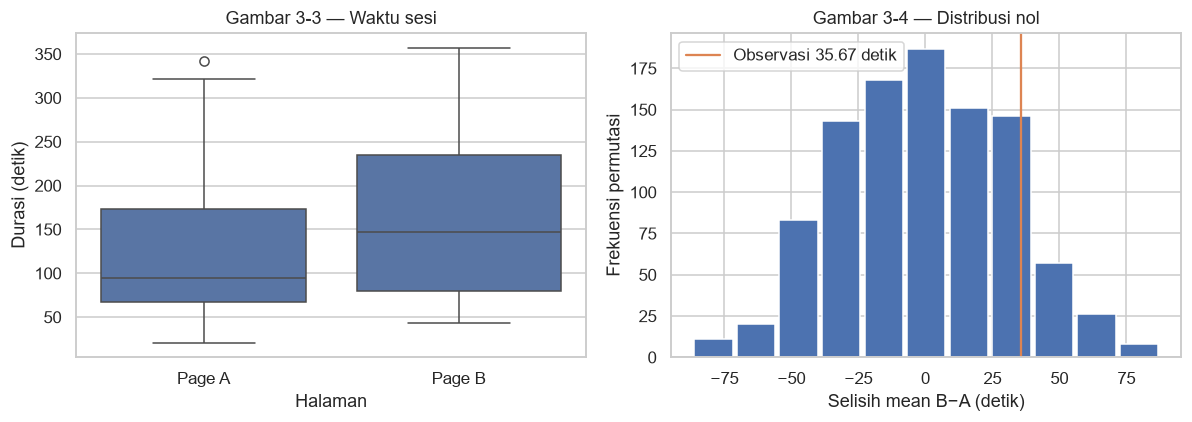

In [20]:
a=session.loc[session.Page=='Page A','Time']
b=session.loc[session.Page=='Page B','Time']
observed=b.mean()-a.mean()
rng_perm=np.random.default_rng(SEED)
perm_times=np.array([perm_diff_b_minus_a(session.Time,len(a),len(b),rng_perm) for _ in range(1000)])
p_times=monte_carlo_p(perm_times,observed)
print(f'Mean A={a.mean():.4f}, mean B={b.mean():.4f}; B−A={observed:.5f} detik')
print(f'Proporsi strict > (gaya buku): {np.mean(perm_times>observed):.4f}')
print(f'p Monte Carlo (ties + koreksi): {p_times:.4f}')
print(f'SE Monte Carlo aproksimasi: {np.sqrt(p_times*(1-p_times)/1000):.4f}')
fig,axes=plt.subplots(1,2,figsize=(11,4))
sns.boxplot(data=session,x='Page',y='Time',ax=axes[0])
axes[0].set(title='Gambar 3-3 — Waktu sesi',xlabel='Halaman',ylabel='Durasi (detik)')
axes[1].hist(perm_times,bins=11,rwidth=.9)
axes[1].axvline(observed,color='C1',label=f'Observasi {observed:.2f} detik')
axes[1].set(title='Gambar 3-4 — Distribusi nol',xlabel='Selisih mean B−A (detik)',ylabel='Frekuensi permutasi')
axes[1].legend(); plt.tight_layout(); plt.show()
assert np.isclose(observed,35.6666666667)

**Interpretasi dan catatan belajar.** B unggul sekitar 35,67 detik pada sampel, tetapi selisih sebesar itu masih cukup sering muncul di bawah pengacakan. P-value di atas 0,05 berarti bukti belum cukup untuk menolak H0 pada alpha 5%; bukan bukti bahwa kedua halaman identik. P buku 0,121/0,126 berasal dari urutan acak berbeda.

## Exhaustive and Bootstrap Permutation Tests

Permutation test dapat dilakukan dengan beberapa pendekatan.

### Exhaustive Permutation Test

Pada exhaustive permutation test, seluruh kemungkinan pembagian data dihitung. Karena jumlah kemungkinan dapat meningkat sangat cepat ketika ukuran data bertambah, metode ini terutama sesuai untuk dataset dengan ukuran relatif kecil.

Pendekatan ini juga disebut sebagai **exact test**, karena seluruh kemungkinan permutasi diperhitungkan.

### Bootstrap Permutation Test

Pada bootstrap permutation test, proses pengambilan sampel dilakukan **dengan replacement**. Artinya, satu observasi dapat terpilih kembali dalam satu proses resampling.

Pendekatan ini berbeda dengan permutation test biasa yang melakukan pengacakan tanpa replacement.

Perbedaan utama kedua pendekatan tersebut adalah:

- **Permutation biasa:** sampling tanpa replacement.
- **Exhaustive permutation:** seluruh kemungkinan pembagian dihitung.
- **Bootstrap permutation:** sampling dilakukan dengan replacement.

Dalam praktik data science, perbedaan tersebut tidak selalu menjadi faktor utama. Pemilihan metode lebih bergantung pada tujuan analisis dan karakteristik data.

In [21]:
print('Banyak alokasi A/B yang mungkin:',format(math.comb(36,21),','))

Banyak alokasi A/B yang mungkin: 5,567,902,560


## Statistical Significance and p-Values

**Statistical significance** digunakan untuk mengevaluasi apakah hasil eksperimen cukup ekstrem dibandingkan hasil yang mungkin muncul karena variasi acak berdasarkan null model.

Dalam pengujian hipotesis, kita tidak hanya melihat besar kecilnya perbedaan antara kelompok. Kita juga perlu mempertimbangkan seberapa sering perbedaan dengan ukuran yang sama atau lebih ekstrem dapat muncul apabila null hypothesis benar.

Konsep ini menjadi dasar penggunaan **p-value**.

Secara sederhana:

> Semakin jarang hasil seperti yang diamati muncul berdasarkan null model, semakin kecil p-value yang diperoleh.

Statistical significance tidak sama dengan ukuran atau pentingnya efek secara praktis. Suatu efek dapat memiliki bukti statistik tertentu tetapi tetap memiliki ukuran efek yang kecil secara praktis.

,Price A,Price B
Conversion,200,182
No conversion,23539,22406


A=0.8425%; B=0.8057%
Selisih A−B=0.036758 poin persentase; lift relatif=4.562%
p permutasi satu sisi = 0.3546


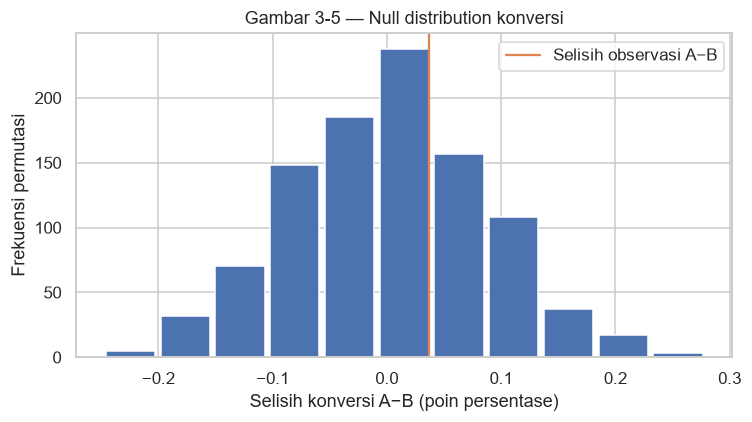

In [22]:
conversions=pd.DataFrame({'Price A':[200,23539],'Price B':[182,22406]},index=['Conversion','No conversion'])
display(conversions)
n_a,n_b=23739,22588
rate_a,rate_b=200/n_a,182/n_b
obs_conversion=100*(rate_a-rate_b)
conversion=np.r_[np.zeros(45945,dtype=int),np.ones(382,dtype=int)]
rng_conversion=np.random.default_rng(SEED)
perm_conversion=np.array([-100*perm_diff_b_minus_a(conversion,n_a,n_b,rng_conversion) for _ in range(1000)])
p_conversion=monte_carlo_p(perm_conversion,obs_conversion)
print(f'A={100*rate_a:.4f}%; B={100*rate_b:.4f}%')
print(f'Selisih A−B={obs_conversion:.6f} poin persentase; lift relatif={(rate_a/rate_b-1)*100:.3f}%')
print(f'p permutasi satu sisi = {p_conversion:.4f}')
plt.hist(perm_conversion,bins=11,rwidth=.9)
plt.axvline(obs_conversion,color='C1',label='Selisih observasi A−B')
plt.title('Gambar 3-5 — Null distribution konversi')
plt.xlabel('Selisih konversi A−B (poin persentase)'); plt.ylabel('Frekuensi permutasi')
plt.legend(); plt.tight_layout(); plt.show()

## Interpretasi Permutation Test

Permutation test digunakan untuk melihat apakah perbedaan yang diamati antara dua kelompok masih berada dalam rentang variasi yang dapat dihasilkan secara acak.

Pada analisis Page A dan Page B, distribusi hasil permutasi merepresentasikan kondisi ketika data dari kedua halaman dianggap berasal dari kondisi yang sama dan perbedaan kelompok hanya terjadi karena proses pengacakan.

Jika nilai perbedaan yang diamati berada di dalam sebagian besar distribusi permutasi, maka perbedaan tersebut masih dapat dijelaskan oleh variasi acak.

Sebaliknya, jika nilai observasi berada pada bagian yang sangat ekstrem dari distribusi permutasi, maka hasil tersebut relatif jarang terjadi berdasarkan null model.

Dengan demikian, permutation test tidak hanya melihat apakah rata-rata kedua kelompok berbeda, tetapi juga mengevaluasi apakah perbedaan tersebut cukup ekstrem dibandingkan variasi yang dihasilkan secara acak.

## p-Value

**p-value** adalah probabilitas untuk memperoleh hasil yang sama ekstrem atau lebih ekstrem daripada hasil yang diamati, dengan asumsi bahwa null hypothesis atau null model benar.

Dalam permutation test, p-value dapat diperkirakan dengan menghitung proporsi hasil permutasi yang sama atau lebih ekstrem daripada statistik observasi.

Secara sederhana:

p ≈              jumlah hasil permutasi yang sama atau lebih ekstrem

          ───────────────────────────────────────────────

                 jumlah seluruh permutasi


Sebagai contoh, apabila dari 1.000 permutasi terdapat 50 hasil yang sama atau lebih ekstrem daripada observasi, maka estimasi p-value adalah sekitar 0,05.

Semakin kecil p-value, semakin sedikit hasil ekstrem yang dihasilkan oleh null model.

In [23]:
chi_conv,p_conv_two,df_conv,_=stats.chi2_contingency(conversions.T.to_numpy(),correction=True)
p_conv_one=p_conv_two/2 if rate_a>=rate_b else 1-p_conv_two/2
p_conv_exact=stats.hypergeom.sf(199,46327,382,23739)
display(pd.Series({'p permutasi Monte Carlo':p_conversion,
                   'p pendekatan buku (continuity corrected, satu sisi)':p_conv_one,
                   'p exact hypergeometric (A≥200)':p_conv_exact}).to_frame('hasil'))

,hasil
p permutasi Monte Carlo,0.354645
"p pendekatan buku (continuity corrected, satu sisi)",0.349780
p exact hypergeometric (A≥200),0.349938


**Interpretasi dan catatan belajar.** Nilai sekitar sepertiga menunjukkan data tidak sangat bertentangan dengan H0. Perbedaan permutasi, continuity correction, dan exact berasal dari Monte Carlo serta pendekatan distribusi; tidak perlu dipaksa identik.

## Alpha

**Alpha (α)** adalah batas yang ditentukan sebelum pengujian untuk menentukan tingkat signifikansi statistik.

Nilai yang umum digunakan adalah:

- α = 0,05
- α = 0,01

Secara sederhana, jika p-value berada di bawah nilai alpha yang telah ditentukan, hasil tersebut dikategorikan sebagai statistically significant berdasarkan kriteria pengujian tersebut.

Contoh:

- Jika α = 0,05 dan p-value = 0,03, maka hasil memenuhi kriteria signifikansi 5%.
- Jika α = 0,05 dan p-value = 0,12, maka hasil tidak memenuhi kriteria tersebut.

Nilai alpha merupakan batas keputusan yang ditentukan sebelumnya. Alpha tidak berarti bahwa terdapat probabilitas tertentu bahwa hipotesis penelitian benar atau salah.

## Type 1 and Type 2 Errors

Dalam pengujian hipotesis terdapat dua jenis kesalahan keputusan utama.

### Type 1 Error

**Type 1 error** terjadi ketika kita menyimpulkan bahwa terdapat efek atau perbedaan, padahal sebenarnya hasil tersebut hanya berasal dari variasi acak.

Dengan kata lain:

> Menyimpulkan ada efek ketika sebenarnya tidak ada efek.

Type 1 error sering dikaitkan dengan nilai alpha karena alpha menentukan tingkat signifikansi yang digunakan dalam pengujian.

### Type 2 Error

**Type 2 error** terjadi ketika kita menyimpulkan bahwa hasil yang diamati dapat dijelaskan oleh variasi acak, padahal sebenarnya terdapat efek yang nyata.

Dengan kata lain:

> Tidak mendeteksi efek yang sebenarnya ada.

Kedua jenis kesalahan tersebut menunjukkan bahwa hasil pengujian statistik tidak memberikan kepastian mutlak. Keputusan statistik selalu memiliki kemungkinan kesalahan.

## Data Science and p-Values

Dalam data science, p-value sebaiknya tidak digunakan sebagai satu-satunya dasar untuk menilai suatu eksperimen.

P-value terutama menjawab pertanyaan mengenai kompatibilitas hasil observasi dengan suatu null model. P-value tidak secara langsung menjelaskan apakah suatu efek memiliki dampak praktis yang besar.

Selain itu, semakin banyak pengujian yang dilakukan, semakin besar kemungkinan menemukan hasil yang tampak signifikan hanya karena variasi acak. Oleh karena itu, proses analisis harus mempertimbangkan multiple testing ketika banyak hipotesis atau metrik diuji.

Dalam konteks eksperimen data science, perhatian tidak hanya diberikan pada statistical significance, tetapi juga pada ukuran efek, tujuan eksperimen, kualitas data, desain eksperimen, dan konsekuensi praktis dari hasil yang diperoleh.

## t-Tests

**t-test** merupakan salah satu metode pengujian signifikansi yang umum digunakan untuk membandingkan rata-rata.

Pada kasus dua kelompok dengan data numerik, t-test dapat digunakan untuk mengevaluasi apakah perbedaan rata-rata kedua kelompok cukup besar dibandingkan variasi yang terdapat dalam data.

Dalam notebook ini digunakan **Welch's t-test**, yang tidak mengasumsikan bahwa kedua kelompok memiliki varians yang sama.

Pengujian menghasilkan beberapa komponen utama:

- **t-statistic**: statistik terstandarisasi yang menggambarkan perbedaan relatif terhadap variasi data.
- **p-value**: ukuran seberapa ekstrem hasil tersebut berdasarkan null hypothesis.
- **degrees of freedom**: parameter yang digunakan dalam distribusi referensi t.

t-test dapat dipandang sebagai pendekatan berbasis distribusi untuk pengujian perbedaan dua kelompok, sedangkan permutation test membentuk distribusi pembanding melalui proses resampling.

In [24]:
welch=stats.ttest_ind(a,b,equal_var=False,alternative='less')
t_sm,p_sm,df_sm=sm.stats.ttest_ind(a,b,usevar='unequal',alternative='smaller')
display(pd.DataFrame({'statistik t':[welch.statistic,t_sm],
                      'p satu sisi A<B':[welch.pvalue,p_sm],
                      'df':[welch.df,df_sm]},index=['SciPy','statsmodels']))
assert np.isclose(welch.pvalue,.1408,atol=.0001)

,statistik t,p satu sisi A<B,df
SciPy,-1.098316,0.140762,27.69337
statsmodels,-1.098316,0.140762,27.69337


## Interpretasi t-Test

Pada pengujian Page A dan Page B, t-test digunakan untuk mengevaluasi apakah perbedaan rata-rata waktu kunjungan dapat dijelaskan oleh variasi acak berdasarkan null hypothesis.

Hasil t-test menghasilkan nilai t-statistic dan p-value.

Interpretasi dilakukan dengan membandingkan p-value terhadap alpha yang telah ditentukan.

Jika p-value lebih kecil daripada alpha, hasil pengujian memenuhi kriteria statistical significance yang digunakan.

Jika p-value lebih besar daripada alpha, data tidak memberikan bukti statistik yang cukup berdasarkan kriteria tersebut untuk menyatakan adanya perbedaan.

Dalam interpretasi hasil, p-value tidak boleh dipisahkan dari ukuran perbedaan rata-rata dan konteks eksperimen.

## Multiple Testing

**Multiple testing** terjadi ketika beberapa pengujian statistik dilakukan terhadap dataset yang sama.

Jika satu pengujian menggunakan tingkat signifikansi tertentu, masih terdapat kemungkinan mendapatkan hasil signifikan secara kebetulan. Ketika jumlah pengujian bertambah, peluang mendapatkan setidaknya satu hasil signifikan secara kebetulan juga meningkat.

Contohnya, ketika beberapa halaman web dibandingkan satu sama lain, kita dapat melakukan beberapa pairwise comparisons:

- Page 1 vs Page 2
- Page 1 vs Page 3
- Page 1 vs Page 4
- Page 2 vs Page 3
- Page 2 vs Page 4
- Page 3 vs Page 4

Melakukan banyak pengujian seperti ini meningkatkan risiko kesimpulan yang keliru akibat variasi acak.

Karena itu, ketika terdapat banyak perbandingan, diperlukan metode yang mempertimbangkan multiple testing. Salah satu pendekatan adalah menggunakan pengujian keseluruhan seperti ANOVA sebelum melakukan analisis perbandingan yang lebih spesifik.

In [25]:
m,alpha=20,.05
print(f'P(≥1 salah positif; 20 uji independen) = {1-(1-alpha)**m:.4f}')
print(f'Ambang Bonferroni per uji = {alpha/m:.4f}')

P(≥1 salah positif; 20 uji independen) = 0.6415
Ambang Bonferroni per uji = 0.0025


## Degrees of Freedom

**Degrees of freedom (df)** merupakan jumlah nilai yang masih bebas untuk berubah ketika terdapat suatu batasan tertentu dalam perhitungan statistik.

Sebagai contoh, jika terdapat 10 observasi dan rata-ratanya telah ditentukan, maka setelah 9 nilai diketahui, nilai ke-10 tidak lagi bebas karena harus memenuhi rata-rata tersebut. Oleh karena itu, derajat kebebasannya adalah:

\[
df = n - 1
\]

Degrees of freedom digunakan dalam berbagai distribusi statistik, termasuk t-distribution, F-distribution, dan chi-square distribution.

Dalam pengujian statistik, degrees of freedom membantu menentukan bentuk distribusi referensi yang digunakan untuk menghitung statistical significance.

## ANOVA

**ANOVA (Analysis of Variance)** digunakan untuk membandingkan rata-rata dari lebih dari dua kelompok.

Ketika hanya terdapat dua kelompok, perbedaan rata-rata dapat dianalisis secara langsung. Namun, ketika terdapat beberapa kelompok, melakukan seluruh pairwise comparisons akan meningkatkan jumlah pengujian dan risiko false positive.

ANOVA menggunakan pendekatan yang berbeda. Alih-alih langsung membandingkan setiap pasangan kelompok, ANOVA mengevaluasi apakah variasi **antar kelompok** cukup besar dibandingkan dengan variasi **di dalam kelompok**.

Secara konseptual, statistik F membandingkan:

\[
F =
\frac{\text{variasi antar kelompok}}
{\text{variasi dalam kelompok}}
\]

Pada dataset `four_sessions.csv`, terdapat empat kelompok halaman:

- Page 1
- Page 2
- Page 3
- Page 4

Pertanyaan yang ingin dijawab adalah apakah perbedaan rata-rata waktu kunjungan keempat halaman dapat dijelaskan oleh variasi acak, atau terdapat bukti bahwa setidaknya terdapat perbedaan antara rata-rata kelompok.

### Hipotesis ANOVA

**H₀:** seluruh kelompok memiliki rata-rata yang sama.

**H₁:** tidak semua rata-rata kelompok sama.

Jika statistik F relatif besar, berarti variasi antar kelompok lebih besar dibandingkan variasi di dalam kelompok. Nilai tersebut kemudian dibandingkan dengan distribusi F untuk memperoleh p-value.

ANOVA merupakan pengujian keseluruhan. Jika hasilnya menunjukkan adanya perbedaan, analisis tambahan diperlukan untuk menentukan kelompok mana yang berbeda.

,mean durasi (detik)
Page,
Page 1,172.8
Page 2,182.6
Page 3,175.6
Page 4,164.6


Grand mean dari data=173.9000; variance mean=55.4267; p permutasi=0.0803


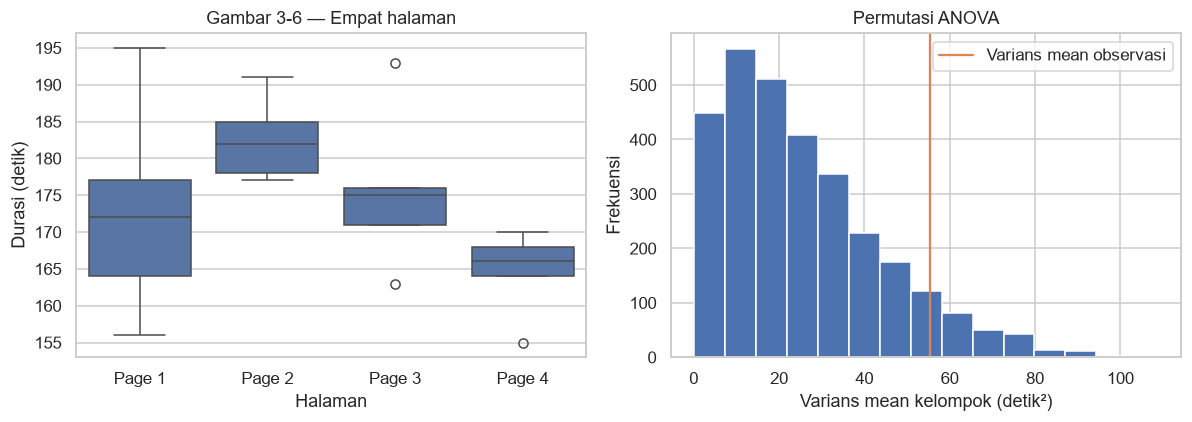

In [26]:
page_means=four.groupby('Page').Time.mean()
obs_var=page_means.var(ddof=1)
rng_anova=np.random.default_rng(SEED)
labels=four.Page.to_numpy()
values=four.Time.to_numpy()
groups=[np.flatnonzero(labels==p) for p in sorted(four.Page.unique())]
perm_var=[]
for _ in range(3000):
    shuffled=rng_anova.permutation(values)
    perm_var.append(np.var([shuffled[idx].mean() for idx in groups],ddof=1))
perm_var=np.asarray(perm_var)
p_anova_perm=monte_carlo_p(perm_var,obs_var)
display(page_means.to_frame('mean durasi (detik)'))
print(f'Grand mean dari data={four.Time.mean():.4f}; variance mean={obs_var:.4f}; p permutasi={p_anova_perm:.4f}')
fig,axes=plt.subplots(1,2,figsize=(11,4))
sns.boxplot(data=four,x='Page',y='Time',ax=axes[0])
axes[0].set(title='Gambar 3-6 — Empat halaman',xlabel='Halaman',ylabel='Durasi (detik)')
axes[1].hist(perm_var,bins=15)
axes[1].axvline(obs_var,color='C1',label='Varians mean observasi')
axes[1].set(title='Permutasi ANOVA',xlabel='Varians mean kelompok (detik²)',ylabel='Frekuensi')
axes[1].legend(); plt.tight_layout(); plt.show()

## Interpretasi ANOVA

Pada analisis `four_sessions.csv`, terdapat empat kelompok halaman yang dibandingkan. Rata-rata waktu kunjungan masing-masing halaman tidak identik, tetapi perbedaan rata-rata tersebut perlu dibandingkan dengan variasi yang terdapat di dalam kelompok.

ANOVA menguji apakah variasi antar kelompok cukup besar dibandingkan dengan variasi dalam kelompok untuk dianggap tidak biasa berdasarkan null model.

Hipotesis yang digunakan adalah:

- **H₀:** rata-rata waktu kunjungan seluruh halaman sama.
- **H₁:** setidaknya terdapat satu rata-rata kelompok yang berbeda.

Hasil permutation test pada contoh ini menghasilkan p-value sekitar **0,093**. Dengan tingkat signifikansi 5%, nilai tersebut berada di atas 0,05 sehingga hasil pengamatan masih dapat dijelaskan oleh variasi acak berdasarkan null model.

Hal ini tidak berarti bahwa keempat halaman pasti memiliki rata-rata yang sama. Artinya, data yang tersedia belum memberikan bukti statistik yang cukup berdasarkan batas signifikansi 5% untuk menyimpulkan adanya perbedaan rata-rata antar halaman.

## F-Statistic

Selain permutation test, ANOVA dapat dilakukan menggunakan **F-statistic**.

F-statistic membandingkan variasi antar kelompok dengan variasi di dalam kelompok:

\[
F =
\frac{\text{variasi antar kelompok}}
{\text{variasi dalam kelompok}}
\]

Jika variasi antar kelompok relatif kecil dibandingkan dengan variasi dalam kelompok, nilai F akan relatif kecil.

Sebaliknya, jika rata-rata kelompok berjauhan sementara variasi di dalam masing-masing kelompok relatif kecil, nilai F akan menjadi lebih besar.

Dalam ANOVA, F-statistic digunakan bersama distribusi F untuk memperoleh p-value berdasarkan pendekatan statistik parametrik.

In [27]:
anova_model=smf.ols('Time ~ C(Page)',data=four).fit()
anova_table=sm.stats.anova_lm(anova_model)
f_result=stats.f_oneway(*[four.loc[four.Page==p,'Time'] for p in sorted(four.Page.unique())])
display(anova_table)
print(f'SciPy F={f_result.statistic:.6f}; p={f_result.pvalue:.6f}')
assert np.isclose(f_result.statistic,anova_table['F'].iloc[0])
assert np.isclose(f_result.pvalue,.0776,atol=.0001)
# Contoh dekomposisi observasi pertama: grand mean + efek kelompok + residual.
first=four.iloc[0]
grand=four.Time.mean(); group_mean=page_means.loc[first.Page]
display(pd.Series({'grand mean':grand,'efek kelompok':group_mean-grand,
                  'residual':first.Time-group_mean,'jumlah':grand+(group_mean-grand)+(first.Time-group_mean)}))

,df,sum_sq,mean_sq,F,PR(>F)
C(Page),3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN


SciPy F=2.739825; p=0.077586


grand mean       173.9
efek kelompok     -1.1
residual          -8.8
jumlah           164.0
dtype: float64

## Interpretasi F-Statistic

Pada data `four_sessions.csv`, ANOVA menghasilkan:

- **F-statistic ≈ 2,74**
- **p-value ≈ 0,0776**

Nilai F menunjukkan bahwa variasi antar rata-rata kelompok lebih besar daripada variasi residual di dalam kelompok. Namun, nilai F harus dilihat bersama p-value untuk menentukan seberapa ekstrem hasil tersebut berdasarkan null model.

Dengan α = 0,05:

\[
p = 0,0776 > 0,05
\]

Sehingga hasil tersebut tidak memenuhi kriteria statistical significance pada tingkat 5%.

Dengan kata lain, berdasarkan pendekatan ANOVA ini, data belum memberikan bukti statistik yang cukup untuk menyatakan bahwa rata-rata waktu kunjungan keempat halaman berbeda.

## Two-Way ANOVA

**Two-way ANOVA** digunakan ketika terdapat dua faktor yang ingin dianalisis terhadap suatu variabel respons.

Berbeda dengan one-way ANOVA yang hanya mempertimbangkan satu faktor, two-way ANOVA memungkinkan kita mengevaluasi:

1. pengaruh faktor pertama;
2. pengaruh faktor kedua; dan
3. interaksi antara kedua faktor.

Sebagai contoh, suatu eksperimen dapat memiliki faktor:

- **Faktor A:** jenis halaman;
- **Faktor B:** jenis perangkat.

Variabel responsnya dapat berupa waktu kunjungan pengguna.

Dengan two-way ANOVA, analisis tidak hanya menanyakan apakah jenis halaman berpengaruh terhadap waktu kunjungan, tetapi juga apakah jenis perangkat memiliki pengaruh dan apakah efek jenis halaman berbeda bergantung pada jenis perangkat.

Interaksi menjadi penting karena pengaruh satu faktor dapat berubah pada tingkat faktor lainnya.

Secara konseptual, model two-way ANOVA dapat dituliskan sebagai:

\[
Y = \text{efek faktor A} +
\text{efek faktor B} +
\text{efek interaksi} +
\text{error}
\]

Two-way ANOVA digunakan ketika desain eksperimen memang memiliki dua faktor yang ingin dianalisis secara bersamaan.

## Chi-Square Test

**Chi-square test** digunakan untuk menganalisis data berbentuk hitungan atau frekuensi dalam beberapa kategori.

Pada contoh ini, kita ingin mengetahui apakah jumlah klik berbeda berdasarkan **headline** yang digunakan.

Data disusun dalam bentuk contingency table yang berisi jumlah:

- pengguna yang melakukan klik;
- pengguna yang tidak melakukan klik;

untuk setiap headline.

Null hypothesis menyatakan bahwa pola klik tidak berbeda antar headline.

Chi-square statistic mengukur seberapa jauh jumlah yang diamati berbeda dari jumlah yang diharapkan berdasarkan null model.

Secara umum:

\[
\chi^2 =
\sum
\frac{(O_i-E_i)^2}{E_i}
\]

dengan:

- \(O_i\) = jumlah observasi;
- \(E_i\) = jumlah yang diharapkan berdasarkan null hypothesis.

Semakin besar perbedaan antara observed counts dan expected counts, semakin besar nilai chi-square.

In [28]:
clicks=click_rate.pivot(index='Click',columns='Headline',values='Rate').loc[['Click','No-click']]
observed_clicks=clicks.to_numpy()
expected_clicks=np.outer(observed_clicks.sum(axis=1),observed_clicks.sum(axis=0))/observed_clicks.sum()
pearson=(observed_clicks-expected_clicks)/np.sqrt(expected_clicks)
obs_chi=float(np.square(pearson).sum())
display(clicks)
display(pd.DataFrame(expected_clicks,index=clicks.index,columns=clicks.columns))
display(pd.DataFrame(pearson,index=clicks.index,columns=clicks.columns))
print('χ² observasi:',obs_chi)

Headline,Headline A,Headline B,Headline C
Click,,,
Click,14,8,12
No-click,986,992,988


Headline,Headline A,Headline B,Headline C
Click,,,
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


Headline,Headline A,Headline B,Headline C
Click,,,
Click,0.792118,-0.990148,0.198030
No-click,-0.084809,0.106012,-0.021202


χ² observasi: 1.6659394708658917


**Interpretasi dan catatan belajar.** Expected click tiap headline sekitar 11,33. Headline A memiliki klik lebih banyak dari expected dan B lebih sedikit, tetapi besarnya deviasi harus dibandingkan dengan variasi acak.

<a id="c3-25"></a>
## Chi-Square Test: A Resampling Approach

*Acuan: cetak 124; PDF 142. Jenis: Reproduksi dengan perbaikan algoritme permutasi.*

Null model mempertahankan total 34 klik dan membaginya acak ke tiga kelompok **saling lepas** berukuran 1.000. Ini mengikuti algoritme naratif dan implementasi utama repository terbaru.

Kode Python PDF melakukan tiga `random.sample(box,1000)` terpisah sehingga record dapat tumpang tindih antarkelompok dan total klik tidak tetap; itu bukan permutasi dengan margin tetap. Implementasi berikut memperbaikinya dengan satu shuffle dan tiga irisan. Hasil disimpan sebagai NumPy array agar perbandingan elemen tidak mengandalkan perilaku list.

In [29]:
rng_chi=np.random.default_rng(SEED)
box=np.r_[np.ones(34,dtype=int),np.zeros(2966,dtype=int)]
perm_chi=[]
for _ in range(2000):
    counts=rng_chi.permutation(box).reshape(3,1000).sum(axis=1)
    table=np.vstack([counts,1000-counts])
    perm_chi.append(((table-expected_clicks)**2/expected_clicks).sum())
perm_chi=np.asarray(perm_chi)
p_chi_perm=monte_carlo_p(perm_chi,obs_chi)
print(f'χ²={obs_chi:.4f}; p permutasi dengan ties={p_chi_perm:.4f}')
print(f'p strict > (pola kode buku)={np.mean(perm_chi>obs_chi):.4f}')

χ²=1.6659; p permutasi dengan ties=0.4843
p strict > (pola kode buku)=0.4600


**Interpretasi dan catatan belajar.** Expected count dan total margin tetap dalam setiap permutasi. Statistik ini diskret sehingga menyertakan ties dapat mengubah p cukup nyata; perbedaan dengan hasil cetak tidak hanya akibat seed.

<a id="c3-26"></a>
## Chi-Square Test: Statistical Theory

*Acuan: cetak 127; PDF 145. Jenis: Reproduksi Python buku.*

Di bawah independensi dan sampel yang cukup, statistik Pearson mendekati $\chi^2_{(r-1)(c-1)}$. Untuk tabel 2×3, df=2. Expected count kecil dan observasi yang tidak independen dapat merusak pendekatan tersebut. P-value dihitung pada ekor kanan: deviasi lebih besar memberi statistik lebih besar.

χ²=1.6659; df=2; p=0.4348


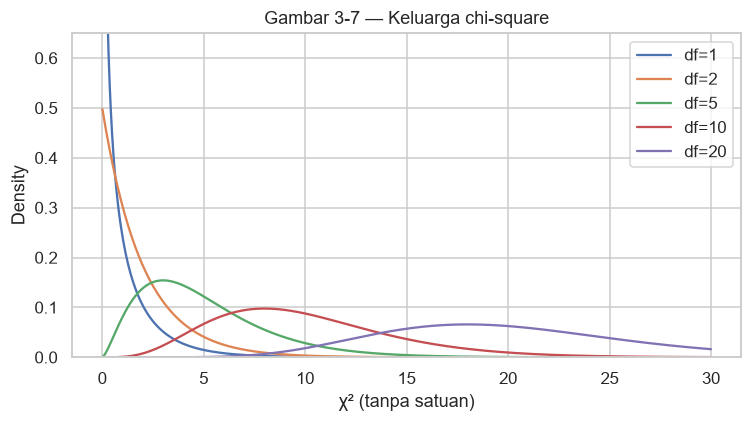

In [30]:
chi,p_chi,df_chi,expected=stats.chi2_contingency(observed_clicks,correction=False)
print(f'χ²={chi:.4f}; df={df_chi}; p={p_chi:.4f}')
assert np.isclose(chi,1.665939,atol=1e-5)
x=np.linspace(.01,30,500)
for d in [1,2,5,10,20]: plt.plot(x,stats.chi2.pdf(x,d),label=f'df={d}')
plt.ylim(0,.65); plt.title('Gambar 3-7 — Keluarga chi-square')
plt.xlabel('χ² (tanpa satuan)'); plt.ylabel('Density'); plt.legend()
plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** P≈0,4348 tidak memberi bukti kuat bahwa headline memengaruhi klik. Kurva df kecil sangat miring; df yang lebih besar menggeser pusat ke kanan. P pendekatan dan p exact/permutasi berbeda karena distribusi diskret hanya didekati kurva kontinu.

<a id="c3-27"></a>
## Fisher’s Exact Test

*Acuan: cetak 128; PDF 146. Jenis: Padanan Python contoh R-only; enumerasi exact.*

Fisher exact mempertahankan margin tabel dan menjumlahkan peluang tabel yang setidaknya se-ekstrem tabel teramati. Untuk tabel 2×3 ini, semua alokasi 34 klik ke tiga kolom dapat dienumerasi dengan murah. Peluang konfigurasi $(a,b,c)$ adalah $\binom{1000}{a}\binom{1000}{b}\binom{1000}{c}/\binom{3000}{34}$, dengan $a+b+c=34$.

**Padanan Python contoh R buku:** gunakan probability ordering (peluang tabel ≤ peluang observasi), bukan otomatis threshold chi-square. Fungsi log-gamma mencegah overflow. Enumerasi ini khusus ukuran/margin contoh, tidak diklaim efisien untuk semua tabel besar; tidak perlu compiler Fortran atau paket tambahan.

In [31]:
def logchoose(n,k):
    return gammaln(n+1)-gammaln(k+1)-gammaln(n-k+1)

observed_logp=sum(logchoose(1000,int(k)) for k in observed_clicks[0])-logchoose(3000,34)
logprobs=[]
for k1 in range(35):
    for k2 in range(35-k1):
        k3=34-k1-k2
        logprobs.append(logchoose(1000,k1)+logchoose(1000,k2)+logchoose(1000,k3)-logchoose(3000,34))
logprobs=np.asarray(logprobs)
assert np.isclose(np.exp(logsumexp(logprobs)),1,atol=1e-9)
p_fisher=float(np.exp(logsumexp(logprobs[logprobs<=observed_logp+1e-10])))
print('Jumlah tabel yang dienumerasi:',len(logprobs))
print(f'Fisher–Freeman–Halton exact 2×3: p={p_fisher:.6f}; buku R≈0,4824')
assert np.isclose(p_fisher,.4824,atol=.0001)

Jumlah tabel yang dienumerasi: 630
Fisher–Freeman–Halton exact 2×3: p=0.482414; buku R≈0,4824


**Interpretasi dan catatan belajar.** Hasil mendekati 0,4824 seperti R di buku. Semua kemungkinan margin dievaluasi, sehingga tidak ada galat Monte Carlo. P exact berbasis peluang tabel dan p permutasi berbasis chi-square memakai definisi ekstrem yang perlu dibedakan meskipun hasil bisa dekat.

<a id="c3-28"></a>
## Relevance for Data Science

*Acuan: cetak 130; PDF 148. Jenis: Reproduksi grafik + uji goodness-of-fit tambahan.*

Chi-square dapat dipakai sebagai penyaring hubungan fitur kategorikal, evaluasi hasil web, atau goodness of fit. Jika dilakukan untuk ribuan fitur, masalah multiple testing kembali muncul; signifikansi juga tidak menjamin manfaat prediksi di data baru.

**Contoh frekuensi digit buku (cetak 129–130):** hipotesis null menganggap sepuluh digit interior sama mungkin. Data menyimpang dari uniform, tetapi uji ini tidak membuktikan sebab penyimpangan atau tindakan curang. Buku menyatakan peneliti terkait akhirnya dibebaskan dari tuduhan. Analisis di bawah hanya membandingkan distribusi digit dengan model uniform.

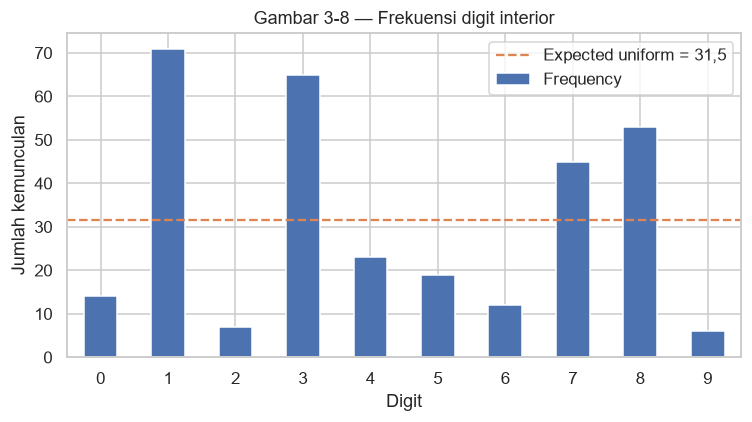

Total digit: 315
Tambahan goodness-of-fit: χ²=174.365; p=7.6e-33


In [32]:
uniform_test=stats.chisquare(digits.Frequency)
ax=digits.plot.bar(x='Digit',y='Frequency',legend=False,rot=0)
ax.axhline(digits.Frequency.sum()/10,color='C1',ls='--',label='Expected uniform = 31,5')
ax.set(title='Gambar 3-8 — Frekuensi digit interior',xlabel='Digit',ylabel='Jumlah kemunculan')
ax.legend(); plt.tight_layout(); plt.show()
print('Total digit:',digits.Frequency.sum())
print(f'Tambahan goodness-of-fit: χ²={uniform_test.statistic:.3f}; p={uniform_test.pvalue:.3g}')

**Interpretasi dan catatan belajar.** Tinggi bar sangat tidak merata dibanding expected 31,5. P kecil menyatakan ketidakcocokan dengan uniform-independen; validitas asumsi pengukuran dan proses pembentukan digit harus dinilai terpisah.

<a id="c3-29"></a>
## Multi-Arm Bandit Algorithm

*Acuan: cetak 131; PDF 149. Jenis: Teori + tambahan kebijakan dari contoh naratif.*

Bandit menyeimbangkan **exploration** (mencoba alternatif untuk belajar) dan **exploitation** (memakai yang saat ini terbaik). Pada contoh buku, A memiliki 10/50 kemenangan, B 2/50, dan C 4/50. Memilih A selamanya mengabaikan ketidakpastian; membagi sama selamanya bisa membuang peluang reward.

Pada epsilon-greedy dengan K arm, setiap arm mendapat probabilitas eksplorasi $\epsilon/K$, sedangkan arm terbaik mendapat tambahan $1-\epsilon$. $\epsilon=1$ berarti seluruhnya acak; $\epsilon=0$ murni greedy. Thompson sampling memelihara distribusi posterior reward, menarik satu nilai untuk tiap arm, dan memilih yang terbesar. Untuk reward Bernoulli, prior Beta diperbarui dengan jumlah sukses dan gagal.

Berikut **tambahan implementasi kebijakan satu langkah**, memakai hitungan naratif buku. Tidak disimulasikan klik pengguna baru. Alokasi adaptif mengubah desain; p-value fixed-design tidak boleh diterapkan tanpa memperhitungkan proses adaptasinya.

In [33]:
wins=np.array([10,2,4]); pulls=np.array([50,50,50]); epsilon=.1
rates=wins/pulls
allocation=np.full(3,epsilon/3)
allocation[np.argmax(rates)]+=1-epsilon
display(pd.DataFrame({'arm':['A','B','C'],'menang':wins,'percobaan':pulls,
                      'rate observasi':rates,'probabilitas epsilon-greedy':allocation}))
rng_bandit=np.random.default_rng(SEED)
posterior_draw=rng_bandit.beta(1+wins,1+pulls-wins)
print('Satu draw Thompson (prior Beta(1,1)):',posterior_draw)
print('Arm dipilih pada draw ini:','ABC'[int(np.argmax(posterior_draw))])

,arm,menang,percobaan,rate observasi,probabilitas epsilon-greedy
0,A,10,50,0.20,0.933333
1,B,2,50,0.04,0.033333
2,C,4,50,0.08,0.033333


Satu draw Thompson (prior Beta(1,1)): [0.21658668 0.08968754 0.10502902]
Arm dipilih pada draw ini: A


**Interpretasi dan catatan belajar.** Probabilitas alokasi adalah aturan keputusan, bukan probabilitas pasti bahwa arm terbaik benar-benar unggul. Satu draw Thompson dapat memilih alternatif karena masih ada ketidakpastian. Ini menghubungkan statistik dengan pengambilan keputusan adaptif.

<a id="c3-30"></a>
## Power and Sample Size

*Acuan: cetak 135; PDF 153. Jenis: Teori.*

Power $=P(\text{tolak }H_0\mid\text{efek tertentu benar})$ tergantung ukuran efek, ukuran sampel, noise, alpha, dan arah uji. Power bukan peluang H1 benar setelah data diamati. Contoh buku ingin membedakan laju dasar 1,1% dari laju yang 10% atau 50% lebih tinggi.

Perencanaan dapat memakai simulasi: bangkitkan dua kelompok dari skenario alternatif, lakukan uji, ulangi, lalu hitung proporsi penolakan. Skenario harus mencerminkan efek minimum yang berguna. Power tidak cukup ditentukan oleh satu hasil eksperimen atau satu p-value.

<a id="c3-31"></a>
## Sample Size

*Acuan: cetak 136; PDF 154. Jenis: Reproduksi Python + pembanding metode.*

Reproduksi memakai `proportion_effectsize` (Cohen h): $h=2\arcsin\sqrt{p_1}-2\arcsin\sqrt{p_0}$. Python buku memasukkan h ke `TTestIndPower`; kita tampilkan hasil itu, lalu bandingkan `NormalIndPower`, pendekatan dua proporsi pada skala arcsine yang lebih dekat dengan fungsi R buku.

Dengan alpha=0,05, power=0,8, alternatif “lebih besar”, ratio=1, hasil n berarti **exposure per kelompok**, bukan jumlah klik atau total dua kelompok. Target 1,21% merupakan peningkatan relatif 10% dari 1,1%, yakni 0,11 poin persentase.

In [34]:
power_rows=[]
for target in [.0121,.0165]:
    h=sm.stats.proportion_effectsize(target,.011)
    n_t=sm.stats.TTestIndPower().solve_power(effect_size=h,alpha=.05,power=.8,ratio=1,alternative='larger')
    n_normal=sm.stats.NormalIndPower().solve_power(effect_size=h,alpha=.05,power=.8,ratio=1,alternative='larger')
    power_rows.append({'p dasar':.011,'p target':target,'Cohen h':h,
                       'n TTestIndPower (buku)':n_t,'n NormalIndPower':n_normal,
                       'n per kelompok dibulatkan (buku)':math.ceil(n_t),
                       'total exposure (buku)':2*math.ceil(n_t)})
display(pd.DataFrame(power_rows))

,p dasar,p target,Cohen h,n TTestIndPower (buku),n NormalIndPower,n per kelompok dibulatkan (buku),total exposure (buku)
0,0.011,0.0121,0.010298,116602.391267,116601.714875,116603,233206
1,0.011,0.0165,0.047468,5488.407720,5487.731209,5489,10978


**Interpretasi dan catatan belajar.** Efek relatif 10% membutuhkan sekitar 116.603 exposure per kelompok, sedangkan efek 50% sekitar 5.489. Mendeteksi perbaikan kecil pada event langka mahal. Perbedaan kecil Python–R berasal dari pendekatan t versus normal; angka final mengikuti output aktual dan pembulatan ke atas.

<a id="c3-32"></a>
## Summary

*Acuan: cetak 139; PDF 157. Jenis: Teori.*

Desain menentukan apakah kelompok layak dibandingkan; statistik tidak memperbaiki randomisasi yang gagal. Pada data sesi, konversi, ANOVA empat halaman, dan headline, perbedaan observasi belum cukup untuk menolak H0 pada alpha 5%. Contoh digit menunjukkan ketidakcocokan distribusi tetapi tidak menetapkan penyebab.

**Latihan:** tulis H0/H1 dan arah statistik untuk dua contoh A/B; jelaskan mengapa 0,0368 poin persentase berbeda dari lift 4,56%; hitung residual df ANOVA; jelaskan mengapa exact tidak sama dengan “pasti benar”; bandingkan tujuan bandit dengan power analysis.

**Bacaan lanjutan buku:** Edgington–Onghena tentang randomization tests; Cobb tentang desain eksperimen; White tentang bandit; Ryan tentang power dan ukuran sampel. Diagram alur inferensi dijelaskan dalam teks; ilustrasi pemasaran tidak disalin.

## Referensi dan atribusi

- Peter Bruce, Andrew Bruce, Peter Gedeck. *Practical Statistics for Data Scientists: 50+ Essential Concepts Using R and Python*, edisi 2, O’Reilly, 2020. ISBN 978-1-492-07294-2, Bab 3.
- [Kode dan dataset resmi pada commit tetap](https://github.com/gedeck/practical-statistics-for-data-scientists/tree/8a6d3bb6468e979c861d4b37215e1413702dfdfa); sumber khusus: `python/code/Chapter 3*.py` dan notebook pendamping. Copyright kode upstream © 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck. Modifikasi untuk tugas: penjelasan Indonesia, seed, API, pemeriksaan hasil, dan tambahan belajar yang ditandai. Lisensi GPL-3.0: lihat [LICENSE](LICENSE).
- Bacaan lanjutan yang disebut buku dirangkum di bagian akhir bab; rujuk buku untuk bibliografi lengkap.

**Refleksi mahasiswa:** tuliskan bagian yang paling sulit, perubahan kode yang Anda coba, dan satu contoh penerapan pada Teknik Komputer. Jangan mengklaim telah melakukan eksperimen nyata dari data contoh ini.